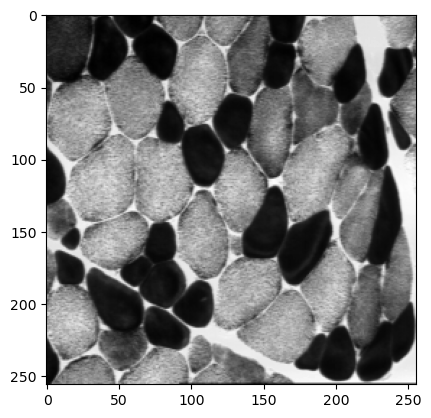

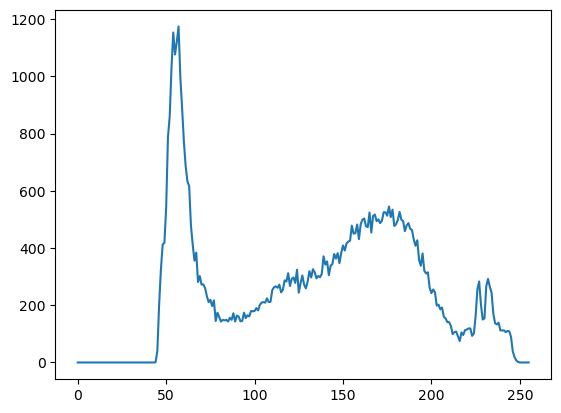

In [1]:
import cv2
import matplotlib.pyplot as plt

muscle = cv2.imread('MUSCLE.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(muscle, cmap='gray')
plt.show()

hist = cv2.calcHist([muscle],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()




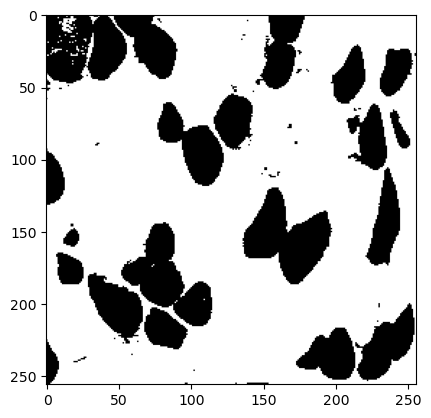

In [10]:
import cv2
import matplotlib.pyplot as plt

S = 80
_, thresholded = cv2.threshold(muscle, S, 255, cv2.THRESH_BINARY)
plt.imshow(thresholded, cmap='gray')
plt.show()



# ¿Cuál es el valor de "S"?

Si vemos el histograma de la imagen original, podemos ver que hay un gran pico al rededor del nivel de intensidad 50. Esto nos indica que la mayoría de los valores más ocuros de esta imagen se encuentran en ese nivel. Yadespués vemos que otras fibras más claras se encuentran entre los niveles de 100 y 200. Entonces un valor aproximado y adecuando para "S" sería uno entre las fibras más oscuras y las medianamente claras, como 80.

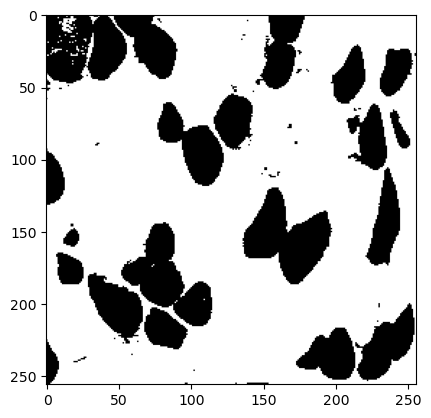

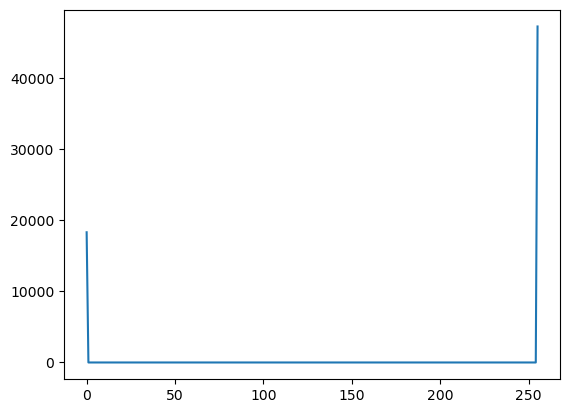

In [12]:
from skimage import exposure
import numpy as np

muscleCalibrada = exposure.rescale_intensity(muscle, in_range=(80, 81))

plt.imshow(muscleCalibrada, cmap='gray')
plt.show()

hist = cv2.calcHist([muscleCalibrada],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()


# Visualice la imagen resultado y su histograma. ¿Cuál es su conclusión?

Al calibrar una imagen con un rango tan reducido como de 80-81, el histograma claramente va a polarizar entre el nivel de 0 para estos valores más oscuros y 255 para todo los demás pixeles. Como resultado, se pierden todos los detalles al quedarnos con la silueta de color uniforme de las fibras más oscuras y el resto de fibras no se pueden distinguir del fondo.

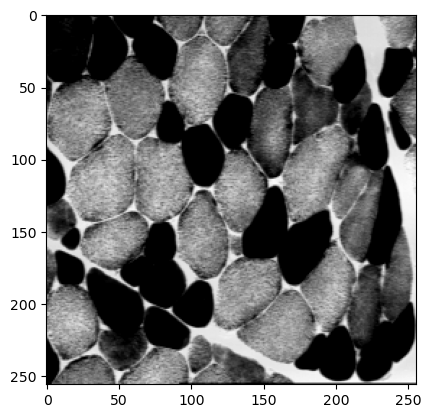

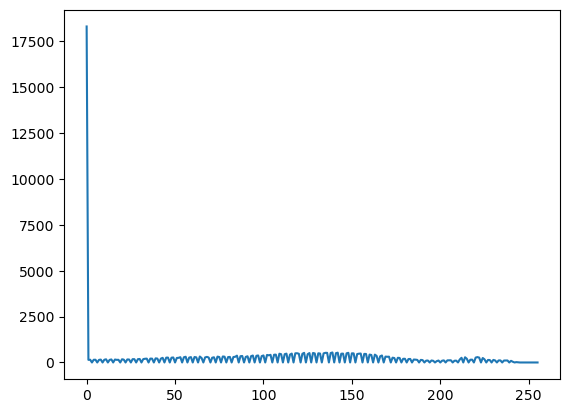

In [14]:
from skimage import exposure
import numpy as np

muscleUmbralizada = exposure.rescale_intensity(muscle, in_range=(80, 255))

plt.imshow(muscleUmbralizada, cmap='gray')
plt.show()

hist = cv2.calcHist([muscleUmbralizada],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

# Conclusión

Al comparar las imagenes de la calibrazión y la umbralización, podemos ver que la calibración del histograma de 80-81 generaba una imagen sin contraste, mientras que la umbralización resalta mejor las fibras oscuras sin alterar de manera extrema el resto de la imagen. En este caso, la umbralización simple es la mejor opción para destacar las fibras oscuras en la imagen.

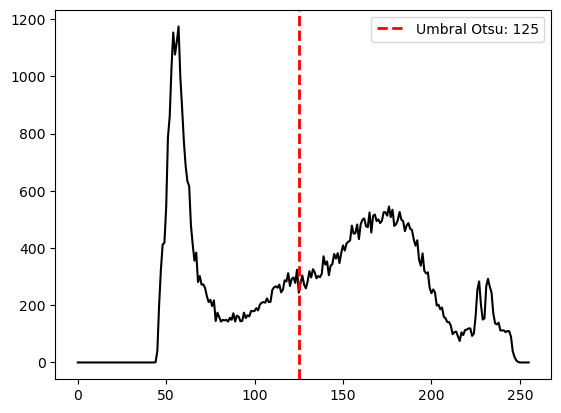

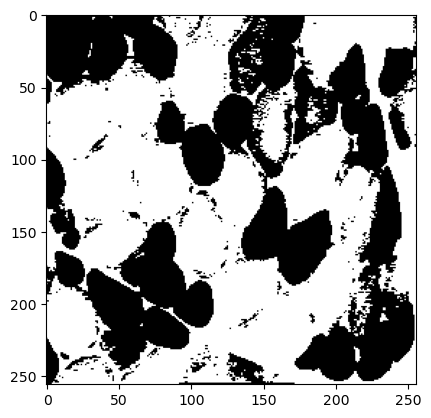

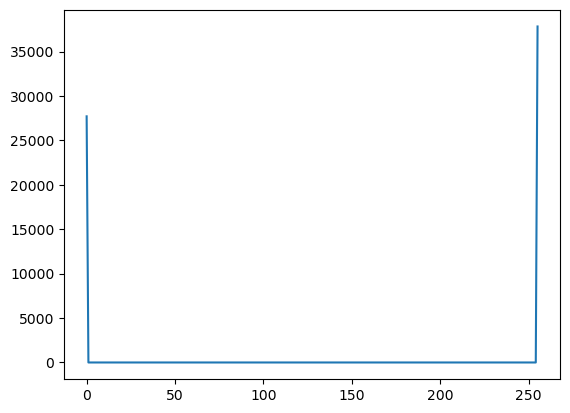

In [22]:
_, otsu_thresh = cv2.threshold(muscle, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
otsu_value = _

hist = cv2.calcHist([muscle], [0], None, [256], [0, 256])
plt.plot(hist, color='black')
plt.axvline(x=otsu_value, color='red', linestyle='dashed', linewidth=2, label=f"Umbral Otsu: {int(otsu_value)}")
plt.legend()
plt.show()

plt.imshow(otsu_thresh, cmap='gray')
plt.show()

hist = cv2.calcHist([otsu_thresh],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()


# ¿Qué resultado dan los métodos de umbralización automática (Otsu) basados sobre la varianza? ¿Cómo eligen estos métodos el umbral a aplicar?

El método de Otsu segmenta la imagen en dos regiones, una para el fondo y otra para el objeto. Esto mediante la elección de un umbral óptimo que maximiza la separación entre ambos grupos. El resultado es una imagen binaria con mejor contraste que la umbralización manual enterior. Mientras que antes se apreciaba el histograma de la imagen original y se tanteaba un valor en base al cual umbralizar, el Otsu analiza el histograma de y busca el umbral que minimiza la varianza dentro de cada región (el fondo y el objeto). Se basa en la distribución estadística de los niveles de gris para encontrar el punto de corte óptimo, en este caso fue 125.